### Imports

In [6]:
import sys, os

import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

%matplotlib widget
from PipelineOrtomosaico import PipelineOrtomosaico
from EspacioCaract import EspacioCaracteristicas

### Pipeline de preparación de datos

In [7]:
# Elección de vuelo.
FECHA = "17ene"

# Para almacenar el polígono (por ahora queda en el default).
POLIGONO = None

# Ejecución del pipeline completo.
resultado = PipelineOrtomosaico.procesar(
    fecha=FECHA,
    poligono=POLIGONO,
    mostrar_graficos=False,
    exportar_metricas=True,
    # Parámetros opcionales:
    indice_otsu="ndvi",
    tamano_minimo_pixeles=50,
    percentil_terreno=1.5,
    dilation_iterations=5,
    gaussian_sigma=15,
)

# Resultados.
rgb         = resultado["rgb_final"]
ms          = resultado["ms_final"]
dsm         = resultado["dsm_final"]
indices     = resultado["indices_enmascarados"]
mascara     = resultado["mascara_binaria"]
chm         = resultado["chm"]
rugosidades = resultado["rugosidades"]

# Mapeo de bandas MS.
bandas_ms = {
    "ms_green":    ms[0],
    "ms_red":      ms[1],
    "ms_red_edge": ms[2],
    "ms_nir":      ms[3] 
}

# Mapeo de bandas RGB.
bandas_rgb = {
    "rgb_red":   rgb[0],
    "rgb_green": rgb[1],
    "rgb_blue":  rgb[2]
}


  PIPELINE — Fecha: 17ene

Ortomosaicos cargados.
Usando coordenadas predeterminadas (modo desarrollo).
[INFO] Recorte aplicado a: RGB | Resol: 0.0200x0.0200 m/px
[INFO] Recorte aplicado a: Multiespectral | Resol: 0.0500x0.0500 m/px
[INFO] Recorte aplicado a: DSM | Resol: 0.0200x0.0200 m/px
Recorte de ROI finalizado.
Alineación espacial de RGB completada.
Alineación espacial del DSM completada.
Normalizando 5 bandas independientemente
     Banda 0: Min=0.000000, Max=0.053344
              → Ya normalizada, solo clip
     Banda 1: Min=0.000000, Max=0.045951
              → Ya normalizada, solo clip
     Banda 2: Min=0.000000, Max=0.126097
              → Ya normalizada, solo clip
     Banda 3: Min=0.000000, Max=0.091173
              → Ya normalizada, solo clip
     Banda 4: Min=0.000000, Max=255.000000
              → Normalizada por percentil 99.9=255.00
Normalizando imagen RGB: Max=255.0000
     → Normalizada: 255.00 → 1.0
Normalización radiométrica completada.
MS:  (5, 621, 1090)  

### Extracción de features

In [8]:
df_features = EspacioCaracteristicas.construir_espacio(
    resultados_pipeline=resultado,
    nombres_bandas_ms=['Verde', 'Rojo', 'Borde_Rojo', 'Infrarrojo_Cercano'],
    nombres_bandas_rgb=['Rojo_Vis', 'Verde_Vis', 'Azul_Vis']
)

display(df_features.head())

Espacio de Características listo: 80,905 píxeles x 21 columnas.


,pos_x,pos_y,Verde,Rojo,Borde_Rojo,Infrarrojo_Cercano,Rojo_Vis,Verde_Vis,Azul_Vis,ndvi,...,savi,gndvi,vari,exg,gi,chm,ratio_ndvi_chm,rug_25cm,rug_55cm,rug_105cm
0,720,164,0.013886,0.015546,0.056342,0.041715,0.496640,0.502731,0.419416,0.457015,...,0.070441,0.500512,0.010502,0.089405,0.242924,0.077549,5.818206,0.065832,0.073750,0.064201
1,707,165,0.012280,0.014324,0.070053,0.044288,0.328662,0.402941,0.275371,0.511223,...,0.080460,0.565840,0.162808,0.201848,0.367903,0.178326,2.850802,0.127148,0.127520,0.101802
2,708,165,0.009838,0.012823,0.070562,0.047798,0.305693,0.458317,0.233251,0.576943,...,0.093579,0.658607,0.287557,0.377689,0.493276,0.169779,3.378305,0.126686,0.125873,0.101308
3,709,165,0.012897,0.013159,0.052543,0.036145,0.333277,0.399181,0.273590,0.466212,...,0.062769,0.474033,0.143623,0.191495,0.362596,0.103123,4.477508,0.122887,0.124330,0.100266
4,718,165,0.011519,0.013745,0.051012,0.041189,0.381389,0.400051,0.326964,0.499573,...,0.074181,0.562910,0.041062,0.091749,0.294742,0.103754,4.768996,0.087233,0.079569,0.077845


### EDA de índices vegetativos

Dispersión
Coeficiente de Variación por índice:
vari     0.487769
exg      0.420863
ndre     0.284862
savi     0.270649
gi       0.208348
gndvi    0.127312
ndvi     0.112233
dtype: float64
--------------------------------------------------


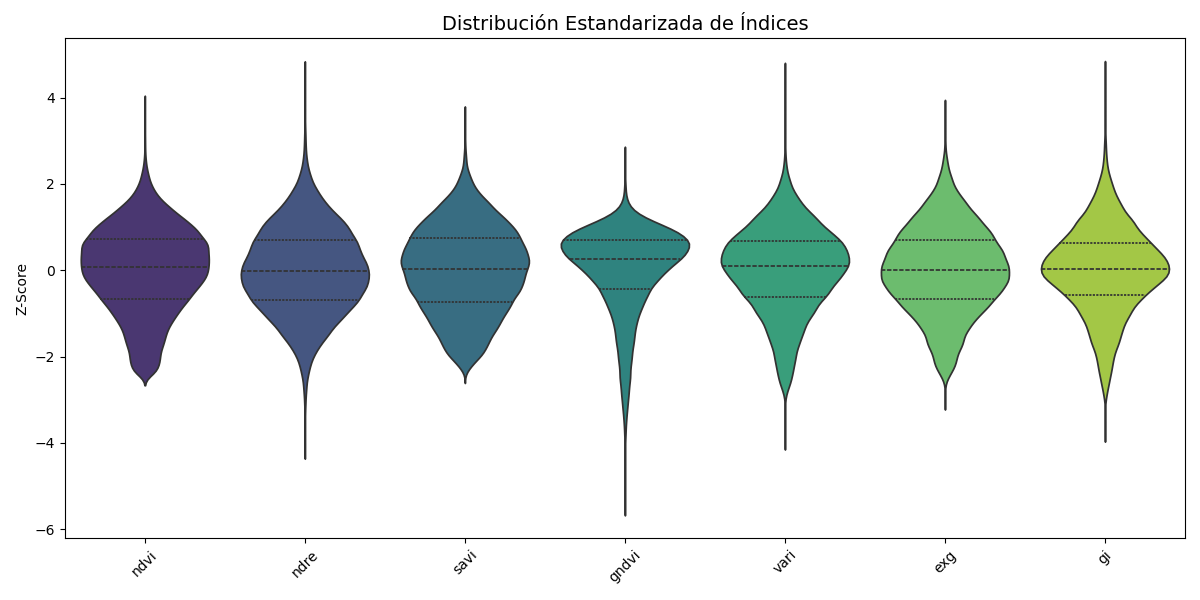

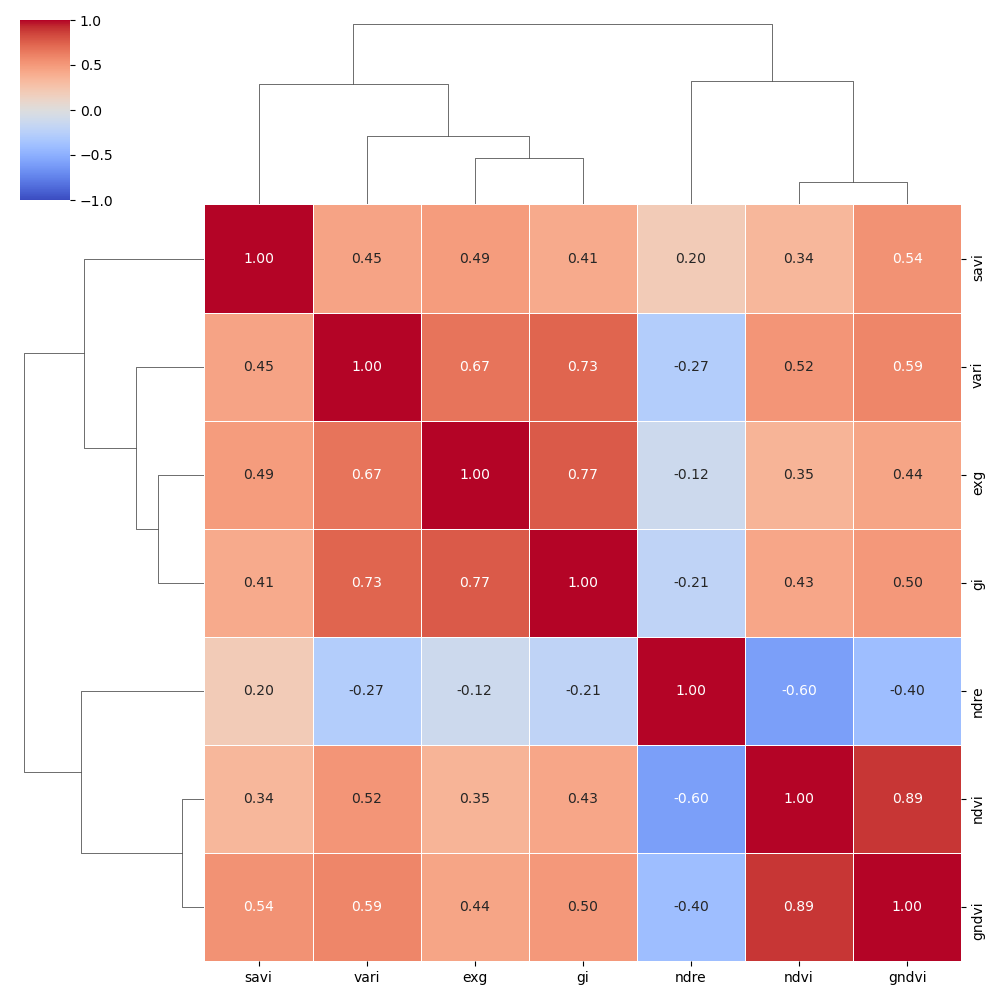

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# DataFrame completo.
df = df_features 

#Aisla los índices vegetativos.
indices_cols = ['ndvi', 'ndre', 'savi', 'gndvi', 'vari', 'exg', 'gi']

# Toma una muestra aleatoria.
if len(df) > 50000:
    df_idx = df[indices_cols].sample(50000, random_state=42)
else:
    df_idx = df[indices_cols]

print("Dispersión")
# Calcula el Coeficiente de Variación. 
cv = (df_idx.std() / df_idx.mean()).abs().sort_values(ascending=False)
print("Coeficiente de Variación por índice:")
print(cv)
print("-" * 50)


# Distribuciones.
# Estandariza los datos (con Z-score) para el gráfico.
df_idx_std = (df_idx - df_idx.mean()) / df_idx.std()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_idx_std, palette="viridis", inner="quartile")
plt.title("Distribución Estandarizada de Índices", fontsize=14)
plt.ylabel("Z-Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Correlación y Clústeres de Redundancia
# Correlación de Spearman.
corr = df_idx.corr(method='spearman')

dist_matrix = 1 - np.abs(corr)
linkage_matrix = hierarchy.linkage(squareform(dist_matrix), method='complete')

# Graficamos el Clustermap
g = sns.clustermap(corr, 
                   row_linkage=linkage_matrix, 
                   col_linkage=linkage_matrix, 
                   annot=True, 
                   fmt=".2f", 
                   cmap="coolwarm", 
                   vmin=-1, vmax=1, 
                   figsize=(10, 10),
                   linewidths=.5)

g.fig.suptitle('Mapa de Correlación', y=1.02, fontsize=14)
plt.show()

In [ ]:

df_features = df_features.drop(columns=['savi'])

print(f"Dataset optimizado. Columnas finales: {df_features.columns.tolist()}")

Dataset optimizado. Columnas finales: ['pos_x', 'pos_y', 'Verde', 'Rojo', 'Borde_Rojo', 'Infrarrojo_Cercano', 'Rojo_Vis', 'Verde_Vis', 'Azul_Vis', 'ndvi', 'ndre', 'gndvi', 'vari', 'exg', 'gi', 'chm', 'ratio_ndvi_chm', 'rug_25cm', 'rug_55cm', 'rug_105cm']


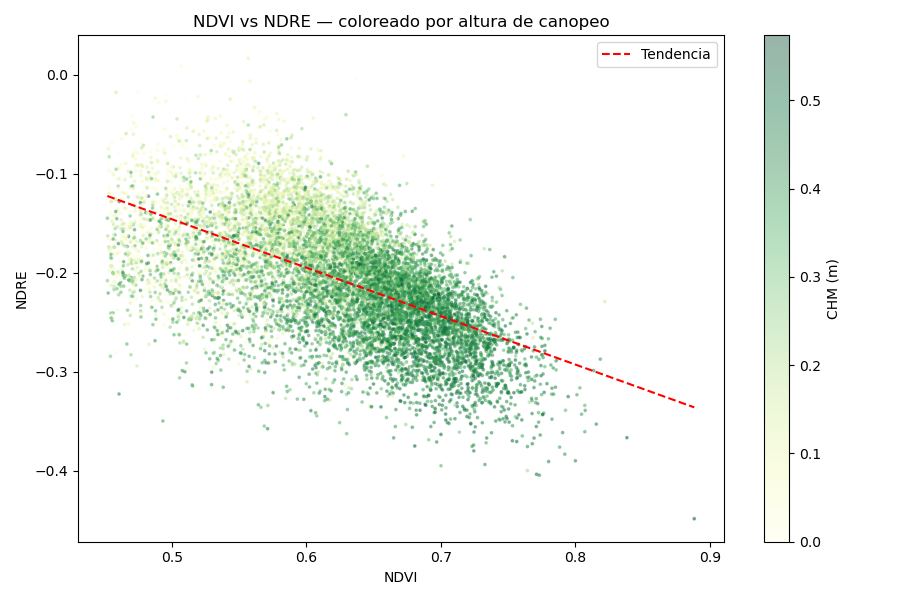

In [11]:
# Relación NDVI vs NDRE segmentada por altura de canopeo.
fig, ax = plt.subplots(figsize=(9, 6))

muestra = df_features.sample(10000, random_state=42)

sc = ax.scatter(
    muestra["ndvi"],
    muestra["ndre"],
    c=muestra["chm"],
    cmap="YlGn",
    alpha=0.4,
    s=3,
)
plt.colorbar(sc, ax=ax, label="CHM (m)")
ax.set_xlabel("NDVI")
ax.set_ylabel("NDRE")
ax.set_title("NDVI vs NDRE — coloreado por altura de canopeo")

# Línea de tendencia.
z = np.polyfit(muestra["ndvi"].dropna(), muestra["ndre"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(muestra["ndvi"].min(), muestra["ndvi"].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label="Tendencia")
ax.legend()
plt.tight_layout()
plt.show()

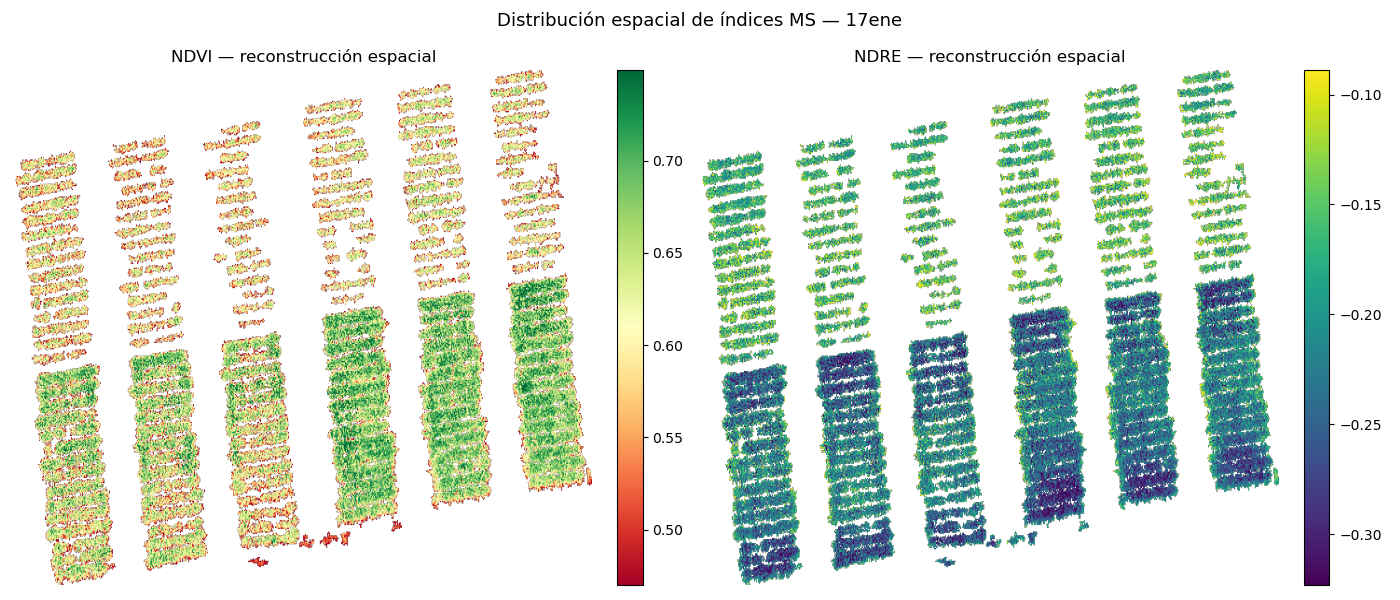

In [13]:
# Reconstrucción espacial de NDVI y NDRE sobre el ROI.
from matplotlib.colors import TwoSlopeNorm

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for ax, indice, cmap in zip(axs, ['ndvi', 'ndre'], ['RdYlGn', 'viridis']):
    pivot = df_features.pivot_table(
        index='pos_y', columns='pos_x', values=indice, aggfunc='mean'
    )
    vmin = np.nanpercentile(pivot.values, 2)
    vmax = np.nanpercentile(pivot.values, 98)
    im = ax.imshow(
        pivot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect='auto',
        origin='upper',
    )
    ax.set_title(f"{indice.upper()} — reconstrucción espacial")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Distribución espacial de índices MS — 17ene", fontsize=13)
plt.tight_layout()
plt.show()

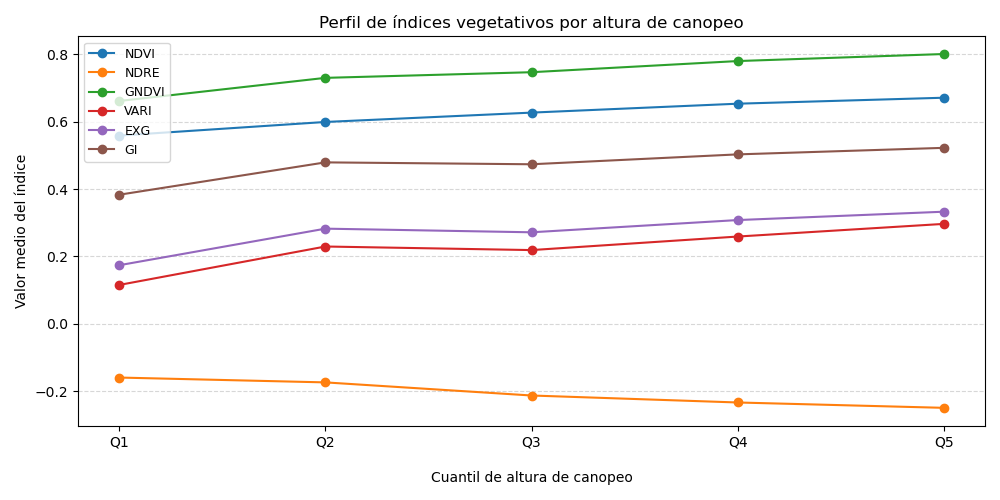

In [15]:
# Comportamiento de índices según altura de canopeo.
indices_para_perfil = ['ndvi', 'ndre', 'gndvi', 'vari', 'exg', 'gi']

df_chm = df_features.dropna(subset=['chm'] + indices_para_perfil).copy()
df_chm['cuantil_chm'] = pd.qcut(df_chm['chm'], q=5, labels=[
    'Q1\n', 'Q2', 'Q3', 'Q4', 'Q5\n'
])

perfil = df_chm.groupby('cuantil_chm', observed=True)[indices_para_perfil].mean()

fig, ax = plt.subplots(figsize=(10, 5))
for col in indices_para_perfil:
    ax.plot(perfil.index, perfil[col], marker='o', label=col.upper())

ax.set_xlabel("Cuantil de altura de canopeo")
ax.set_ylabel("Valor medio del índice")
ax.set_title("Perfil de índices vegetativos por altura de canopeo")
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()